In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X,Y = make_regression(n_samples=4, n_features=1,n_informative=1,n_targets=1, noise=20, random_state=13)

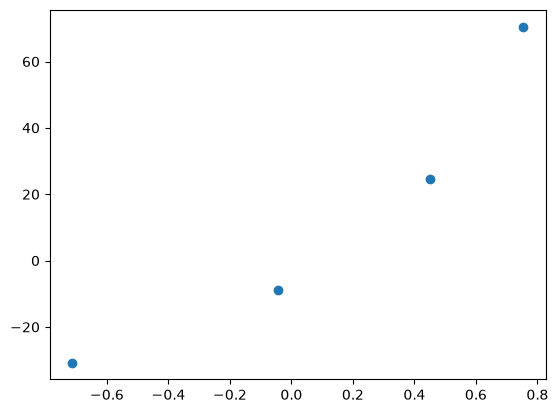

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,Y)

In [4]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[65.27]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.54
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [5]:
reg.coef_

array([65.26584388])

In [6]:
reg.intercept_

np.float64(6.539908210783156)

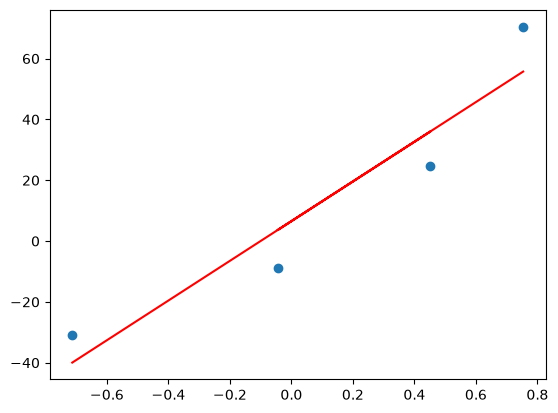

In [7]:
plt.scatter(X,Y)
plt.plot(X,reg.predict(X),color='red')

In [8]:
y_pred=((66.2 * X)+100).reshape(4)

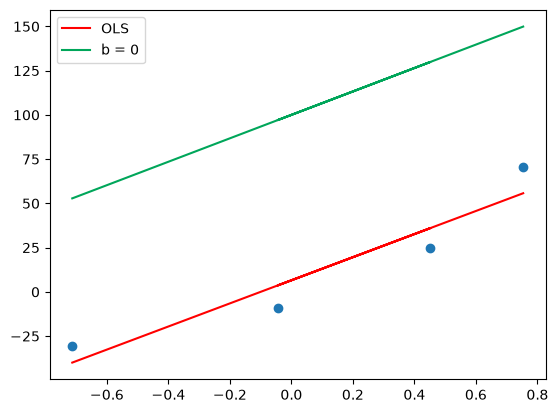

In [9]:
plt.scatter(X,Y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [10]:
m=66.2
b=100
loss_slope=-2 *np.sum(Y-(m*X.ravel()+b))
loss_slope

np.float64(748.5190179509234)

In [11]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(74.85190179509235)

In [12]:
# Calculating the new intercept
b = b - step_size
b

np.float64(25.148098204907654)

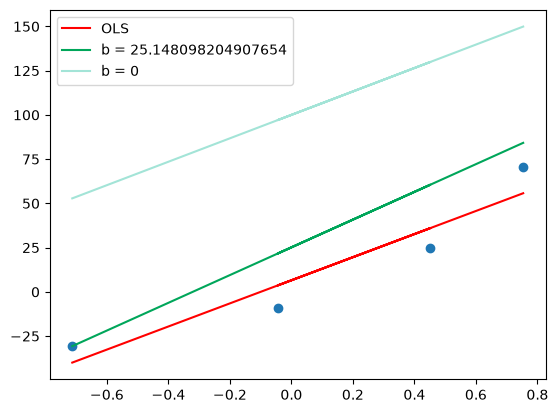

In [13]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,Y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [14]:
# Iteration 2
loss_slope = -2 * np.sum(Y - m*X.ravel() - b)
loss_slope

np.float64(149.70380359018458)

In [15]:
step_size = loss_slope*lr
step_size

np.float64(14.970380359018458)

In [16]:
b = b - step_size
b

np.float64(10.177717845889196)

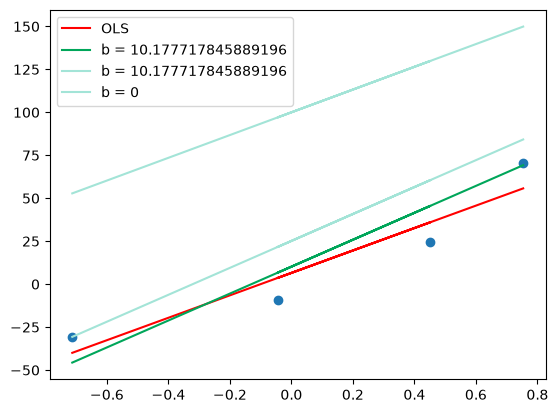

In [17]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,Y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [18]:
# Iteration 3
loss_slope = -2 * np.sum(Y - m*X.ravel() - b)
loss_slope

np.float64(29.940760718036902)

In [19]:
step_size = loss_slope*lr
step_size

np.float64(2.9940760718036903)

In [20]:
b = b - step_size
b

np.float64(7.1836417740855065)

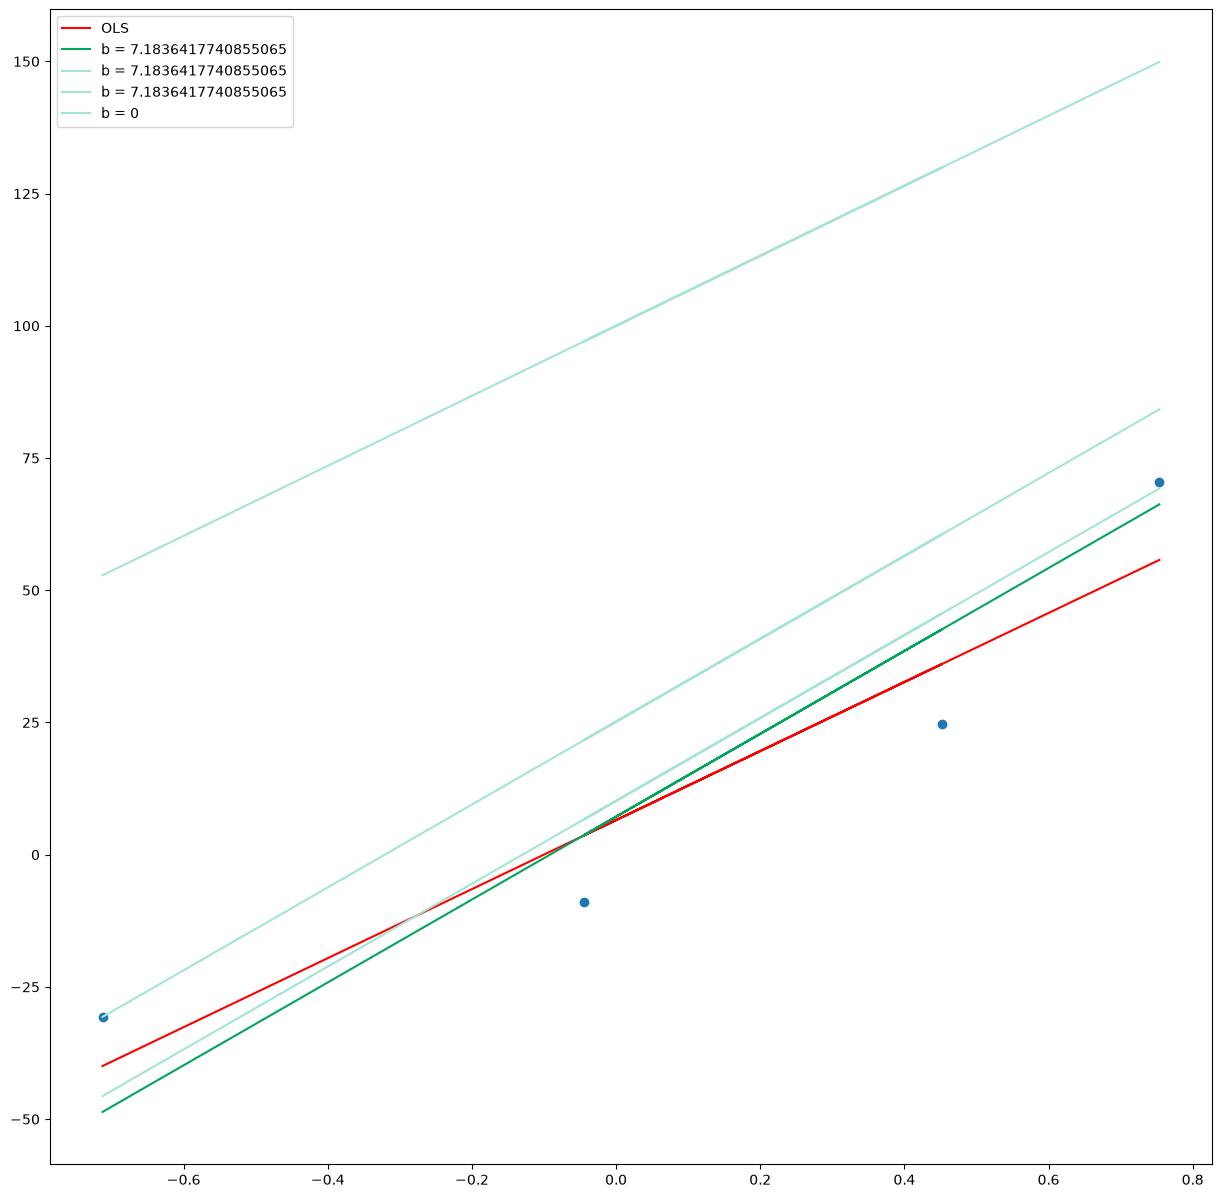

In [21]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,Y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

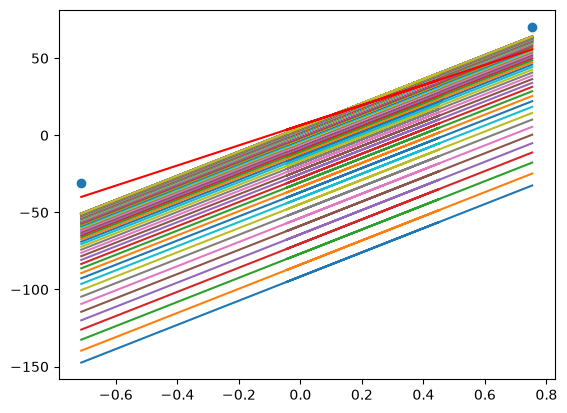

In [28]:
b = -100
m = 78.35
lr = 0.01

epochs = 99

for i in range(epochs):
  loss_slope = -2 * np.sum(Y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.scatter(X,Y)